          exact  abs_err  classes_ok
level                               
clean     1.000      0.0       1.000
noisy     1.000      0.0       1.000
blurry    1.000      0.0       0.975
touching  1.000      0.0       0.925
overlap   0.825      0.2       0.650


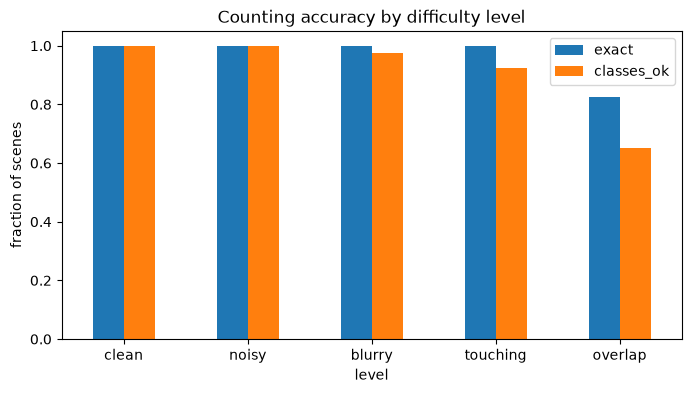

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from src.counting import detect_shapes, draw_result
from src.hard_scenes import generate_hard

CLASSES = ["circle", "triangle", "square", "pentagon", "hexagon"]
MINIMAL = ["n_vertices_4", "circle_fill", "rect_fill", "rect_aspect", "hu1"]

feats = pd.read_csv("data/processed/features.csv")
tr = feats[feats.split == "train"]
model = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                               random_state=0).fit(tr[MINIMAL], tr.label)

hard = generate_hard(40)

rows = []
for r in hard.itertuples():
    res = detect_shapes(cv2.imread(r.path), model, MINIMAL)
    pred = Counter(label for _, label in res)
    row = {"path": r.path, "level": r.level, "true_total": r.total_count, "pred_total": len(res)}
    for c in CLASSES:
        row[f"true_{c}"] = getattr(r, f"n_{c}")
        row[f"pred_{c}"] = pred.get(c, 0)
    rows.append(row)
res = pd.DataFrame(rows)

res["exact"] = res.true_total == res.pred_total
res["abs_err"] = (res.true_total - res.pred_total).abs()
res["classes_ok"] = np.all([res[f"true_{c}"] == res[f"pred_{c}"] for c in CLASSES], axis=0)

summary = res.groupby("level", sort=False)[["exact", "abs_err", "classes_ok"]].mean().round(3)
print(summary)
summary.to_csv("outputs/extension_summary.csv")
res.to_csv("outputs/extension_results.csv", index=False)

summary[["exact", "classes_ok"]].plot.bar(figsize=(8, 4), ylim=(0, 1.05))
plt.title("Counting accuracy by difficulty level")
plt.ylabel("fraction of scenes")
plt.xticks(rotation=0)
plt.savefig("outputs/extension_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

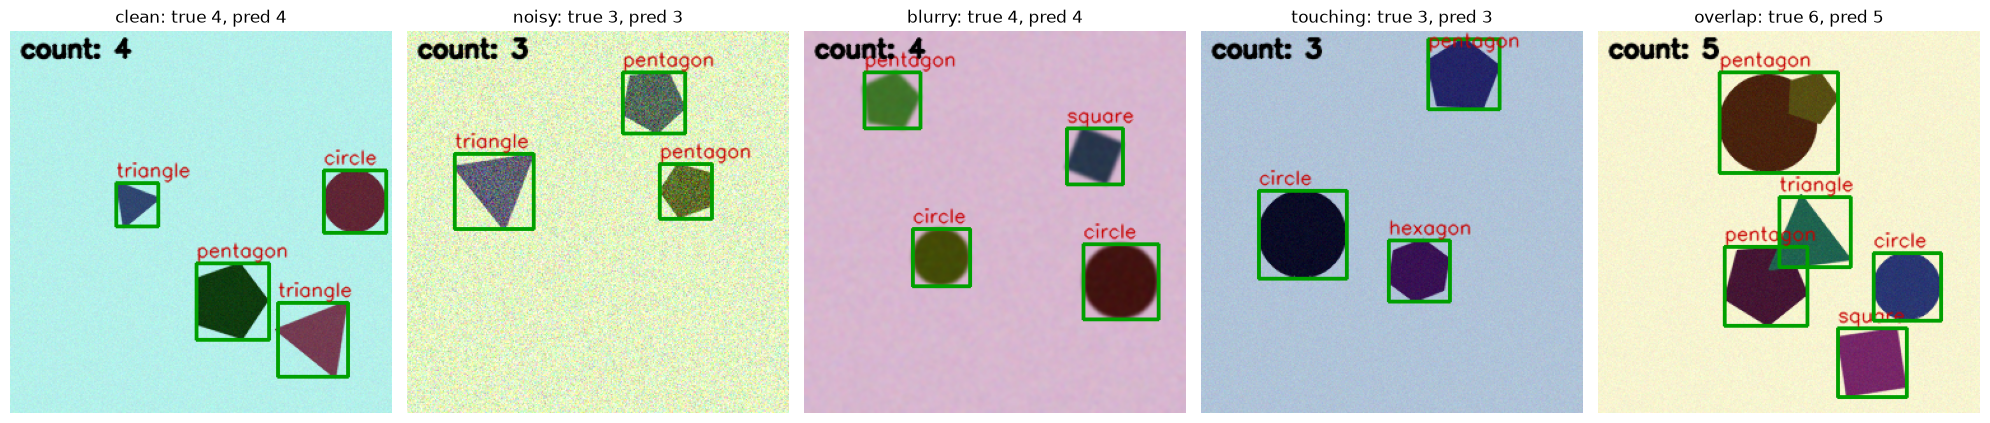

In [2]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4.5))
for ax, lvl in zip(axes, res.level.unique()):
    sub = res[(res.level == lvl) & ~res.exact]
    r = sub.iloc[0] if len(sub) else res[res.level == lvl].iloc[0]
    img = cv2.imread(r.path)
    out = draw_result(img, detect_shapes(img, model, MINIMAL))
    ax.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{lvl}: true {r.true_total}, pred {r.pred_total}")
    ax.axis("off")
plt.tight_layout()
fig.savefig("outputs/extension_failures.png", dpi=150, bbox_inches="tight")
plt.show()

          exact_before  classes_ok_before  abs_err_before  exact_after  \
level                                                                    
clean            1.000              1.000            0.00        1.000   
noisy            1.000              1.000            0.00        1.000   
blurry           1.000              0.975            0.00        1.000   
touching         0.750              0.750            0.25        1.000   
overlap          0.475              0.475            0.75        0.825   

          classes_ok_after  abs_err_after  
level                                      
clean                1.000            0.0  
noisy                1.000            0.0  
blurry               0.975            0.0  
touching             0.925            0.0  
overlap              0.650            0.2  


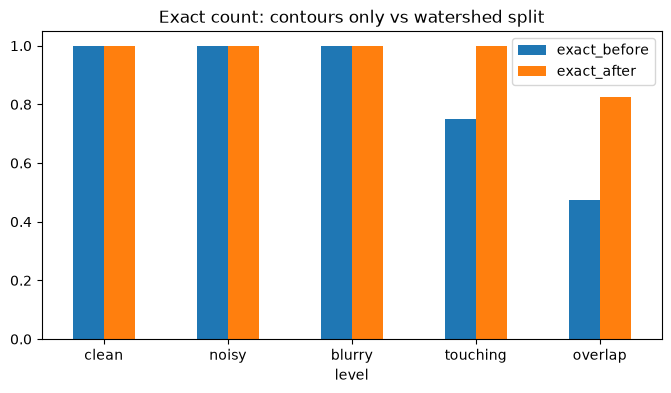

In [3]:
def evaluate(split):
    rows = []
    for r in hard.itertuples():
        out = detect_shapes(cv2.imread(r.path), model, MINIMAL, split=split)
        pred = Counter(l for _, l in out)
        rows.append({"level": r.level,
                     "exact": len(out) == r.total_count,
                     "classes_ok": all(pred.get(c, 0) == getattr(r, f"n_{c}") for c in CLASSES),
                     "abs_err": abs(len(out) - r.total_count)})
    return pd.DataFrame(rows).groupby("level", sort=False).mean().round(3)

cmp = evaluate(False).join(evaluate(True), lsuffix="_before", rsuffix="_after")
print(cmp)
cmp.to_csv("outputs/extension_before_after.csv")

cmp[["exact_before", "exact_after"]].plot.bar(figsize=(8, 4), ylim=(0, 1.05))
plt.title("Exact count: contours only vs watershed split")
plt.xticks(rotation=0)
plt.savefig("outputs/extension_before_after.png", dpi=150, bbox_inches="tight")
plt.show()